<a href="https://colab.research.google.com/github/UKD1211/Macroeconomic_impact_of_gold-_Econ_growth/blob/main/Gold_price_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('default')

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (14,6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

In [ ]:
df = pd.read_excel("/content/Master_Dataset.xlsx")

In [ ]:
df

In [ ]:
#sort dataset

df = df.sort_values("Date").reset_index(drop = True)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace = True)

In [ ]:
gold_price = df['Gold_Price[/10gm]']

In [ ]:
gold_price

In [ ]:
#gold_price_decompose

decomposition = seasonal_decompose(
    gold_price,
    model='additive',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.suptitle(
    "Seasonal Decomposition of Gold Price",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

In [ ]:
# Monthly Gold Return (%)

df['Gold_Return_%'] = (
    df['Gold_Price[/10gm]']
    .pct_change() * 100
)

In [ ]:
gold_return = df['Gold_Return_%'].dropna()

In [ ]:
#Gold Return seasonal Decompose
decomposition_return = seasonal_decompose(
    gold_return,
    model='additive',
    period=12
)

fig = decomposition_return.plot()

fig.set_size_inches(16,10)

plt.suptitle(
    "Seasonal Decomposition of Gold Return",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

In [ ]:
#visual representation of the Stationarity check

In [ ]:
window = 12  # 12 months

rolling_mean = gold_price.rolling(window=window).mean()
rolling_std = gold_price.rolling(window=window).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(15,10),
    sharex=True,
    gridspec_kw={'hspace':0.15}
)

# -------------------------------
# Rolling Mean
# -------------------------------

axes[0].plot(
    gold_price,
    color='royalblue',
    linewidth=2,
    label='Gold Price'
)

axes[0].plot(
    rolling_mean,
    color='crimson',
    linewidth=2.5,
    label='12-Month Rolling Mean'
)

axes[0].set_title(
    'Gold Price with Rolling Mean',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Gold Price (₹/10gm)')
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.3)

# -------------------------------
# Rolling Standard Deviation
# -------------------------------

axes[1].plot(
    rolling_std,
    color='darkgreen',
    linewidth=2.5
)

axes[1].fill_between(
    rolling_std.index,
    rolling_std.values,
    color='limegreen',
    alpha=0.25
)

axes[1].set_title(
    '12-Month Rolling Standard Deviation',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_ylabel('Rolling Std')
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
window = 12

rolling_mean_return = gold_return.rolling(window=window).mean()
rolling_std_return = gold_return.rolling(window=window).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(15,10),
    sharex=True,
    gridspec_kw={'hspace':0.15}
)

# -------------------------------
# Rolling Mean
# -------------------------------

axes[0].plot(
    gold_return,
    color='royalblue',
    linewidth=2,
    label='Gold Return (%)'
)

axes[0].plot(
    rolling_mean_return,
    color='crimson',
    linewidth=2.5,
    label='12-Month Rolling Mean'
)

axes[0].axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

axes[0].set_title(
    'Gold Return with Rolling Mean',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Return (%)')
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.3)

# -------------------------------
# Rolling Standard Deviation
# -------------------------------

axes[1].plot(
    rolling_std_return,
    color='darkgreen',
    linewidth=2.5
)

axes[1].fill_between(
    rolling_std_return.index,
    rolling_std_return.values,
    color='limegreen',
    alpha=0.25
)

axes[1].set_title(
    '12-Month Rolling Standard Deviation',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_ylabel('Rolling Std')
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

# Install once if not installed
!pip install arch

from arch.unitroot import PhillipsPerron

In [ ]:
def stationarity_tests(series, series_name):

    print("="*70)
    print(f"Stationarity Tests : {series_name}")
    print("="*70)

    # -----------------------------
    # ADF TEST
    # -----------------------------
    print("\nADF TEST")
    print("-"*30)

    adf_result = adfuller(series.dropna(), autolag='AIC')

    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"P-value       : {adf_result[1]:.4f}")
    print(f"Lags Used     : {adf_result[2]}")
    print(f"Observations  : {adf_result[3]}")

    print("\nCritical Values")

    for key, value in adf_result[4].items():
        print(f"{key}: {value:.4f}")

    if adf_result[1] < 0.05:
        print("\nConclusion : Reject H0 → Stationary")
    else:
        print("\nConclusion : Fail to Reject H0 → Non-Stationary")

    # -----------------------------
    # KPSS TEST
    # -----------------------------
    print("\n\nKPSS TEST")
    print("-"*30)

    kpss_result = kpss(series.dropna(),
                       regression='c',
                       nlags='auto')

    print(f"KPSS Statistic : {kpss_result[0]:.4f}")
    print(f"P-value        : {kpss_result[1]:.4f}")

    print("\nCritical Values")

    for key, value in kpss_result[3].items():
        print(f"{key}: {value}")

    if kpss_result[1] < 0.05:
        print("\nConclusion : Reject H0 → Non-Stationary")
    else:
        print("\nConclusion : Fail to Reject H0 → Stationary")

    # -----------------------------
    # PHILLIPS-PERRON
    # -----------------------------
    print("\n\nPHILLIPS-PERRON TEST")
    print("-"*30)

    pp = PhillipsPerron(series.dropna())

    print(pp.summary())

In [ ]:
stationarity_tests(
    gold_price,
    "Gold Price"
)

In [ ]:
stationarity_tests(
    gold_return,
    "Gold Return (%)"
)

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15,10))

plot_acf(
    gold_return,
    lags=36,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title(
    "Autocorrelation Function (ACF) - Gold Return",
    fontsize=15,
    fontweight='bold'
)

plot_pacf(
    gold_return,
    lags=36,
    ax=axes[1],
    method='ywm'
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF) - Gold Return",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

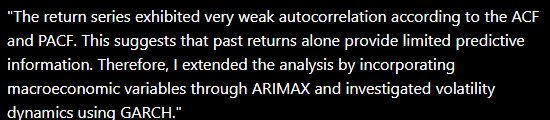

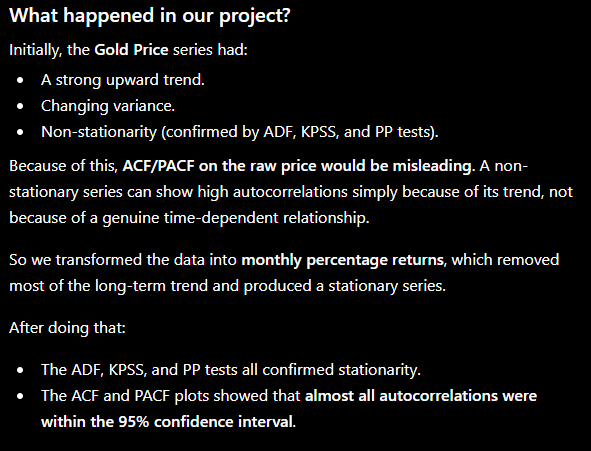

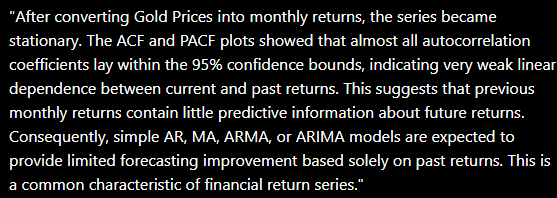

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15,10))

plot_acf(
    gold_price,
    lags=36,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title(
    "Autocorrelation Function (ACF) - Gold price",
    fontsize=15,
    fontweight='bold'
)

plot_pacf(
    gold_price,
    lags=36,
    ax=axes[1],
    method='ywm'
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF) - Gold price",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# **AR models**

In [ ]:
#AR models

from statsmodels.tsa.ar_model import AutoReg

ar_results = {}

for lag in [1,2,3,4,5,6]:

  model = AutoReg(
      gold_return,
      lags = lag,
      old_names = False
  ).fit()

  ar_results[lag] = model

  print("="*60)
  print(f"AR({lag})")
  print("="*60)

  print(model.summary())

  print("\nAIC :", round(model.aic,2))
  print("BIC :", round(model.bic,2))

# **Taken AR(1) model : Yt = 0.9853 + 0.1563*Yt-1**

In [ ]:
ar1 = AutoReg(
    gold_return,
    lags = 1,
    old_names = False
).fit()

In [ ]:
print(ar1.summary())

In [ ]:
fitted = ar1.fittedvalues

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    gold_return,
    label='Actual Gold Return',
    linewidth=2,
    color='royalblue'
)

plt.plot(
    fitted,
    label='AR(1) Fitted',
    linewidth=2,
    color='crimson'
)

plt.title(
    'Gold Return vs AR(1) Fitted Values',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
residuals = ar1.resid

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    residuals,
    color='darkgreen',
    linewidth=1.8
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title(
    'Residuals of AR(1)',
    fontsize=16,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        gold_return.iloc[1:],   # first value has no prediction
        fitted
    )
)

mae = mean_absolute_error(
    gold_return.iloc[1:],
    fitted
)

mape = mean_absolute_percentage_error(
    gold_return.iloc[1:],
    fitted
)

print("MAPE :", mape)

print("RMSE :", rmse)
print("MAE  :", mae)

# **MA models**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

for lags in [1,2,3,4,5]:
  model = ARIMA(
      gold_return,
      order = (0,0,lags),
      enforce_stationarity = False,
      enforce_invertibility = False
  ).fit()

  print("="*60)
  print(f"MA({lags})")
  print("="*60)

  print(model.summary())
  print("\nAIC :", round(model.aic,2))
  print("BIC :", round(model.bic,2))

In [ ]:
ma4 = ARIMA(
    gold_return,
    order = (0,0,4),
    enforce_stationarity = False,
    enforce_invertibility = False
).fit()
print(ma4.summary())

In [ ]:
ma4_fitted = ma4.fittedvalues

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    gold_return,
    label='Actual Gold Return',
    color='royalblue',
    linewidth=2
)

plt.plot(
    ma4_fitted,
    label='MA Fitted',
    color='crimson',
    linewidth=2
)

plt.legend()

plt.grid(alpha=0.3)

plt.title("Gold Return vs MA(4) Fitted Values",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()

plt.show()

In [ ]:
residuals = ma4.resid

plt.figure(figsize=(16,5))

plt.plot(
    residuals,
    color='darkgreen'
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.grid(alpha=0.3)

plt.title(
    "Residuals of MA(4) Model",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        gold_return,
        ma4_fitted
    )
)

mae = mean_absolute_error(
    gold_return,
    ma4_fitted
)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

# **ARMA models**

In [ ]:
arma_orders = [
    (1,1),
    (1,2),
    (1,3),
    (1,4),
    (2,1),
    (2,2),
    (2,4),
    (3,1),
    (3,2),
    (3,4)
]

from statsmodels.tsa.arima.model import ARIMA

arma_models = {}

for p, q in arma_orders:

    print("="*70)
    print(f"ARMA({p},{q})")
    print("="*70)

    model = ARIMA(
        gold_return,
        order=(p,0,q)      # d = 0 because returns are stationary
    ).fit()

    arma_models[(p,q)] = model

    print(model.summary())

    print(f"\nAIC : {model.aic:.2f}")
    print(f"BIC : {model.bic:.2f}")

In [ ]:
ARMA_11 = ARIMA(
    gold_return,
    order = (1,0,1)
).fit()

print(ARMA_11.summary())

In [ ]:
fitted = ARMA_11.fittedvalues

plt.figure(figsize=(16,6))

plt.plot(
    gold_return,
    label="Actual",
    color="royalblue",
    linewidth=2
)

plt.plot(
    fitted,
    label="ARMA Fitted",
    color="crimson",
    linewidth=2
)

plt.legend()

plt.grid(alpha=0.3)

plt.title(
    "Gold Return vs ARMA(1,1) Fitted Values",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
residuals = ARMA_11.resid

plt.figure(figsize=(16,5))

plt.plot(
    residuals,
    color="darkgreen"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.grid(alpha=0.3)

plt.title(
    "Residuals of ARMA",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(gold_return, fitted))
mae = mean_absolute_error(gold_return, fitted)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")